# Классификация нефтегазовых месторождений

## Описание проекта

В проекте решается задача классификации типа месторождения по географическим и геологическим признакам.

Ноутбук отвечает за аналитическую часть проекта: первичный анализ данных, уточнение постановки задачи, проверку гипотез и сравнение моделей. Воспроизводимое обучение и получение предсказаний планируется вынести в `src`-часть проекта.

Анализ и обучение в ноутбуке выполняются только на `train_oil.csv`.  
Файл `oil_test.csv` рассматривается как внешний тестовый набор для последующего получения предсказаний.

Выборка небольшая, поэтому результаты модели стоит интерпретировать с осторожностью.

## Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [2]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Загрузка данных

Загрузим обучающий и тестовый датасеты и проверим, что их структура согласована.

In [3]:
BASE_DIR = Path.cwd()

if not (BASE_DIR / "data").exists() and (BASE_DIR.parent / "data").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data" / "raw"

train = pd.read_csv(DATA_DIR / "train_oil.csv")
test = pd.read_csv(DATA_DIR / "oil_test.csv")

print("Размер train:", train.shape)
print("Размер test:", test.shape)

Размер train: (309, 20)
Размер test: (133, 19)


Обучающий датасет содержит **309 строк и 20 столбцов**, тестовый — **133 строки и 19 столбцов**.

`train_oil.csv` содержит целевую переменную и используется для EDA и обучения моделей.  
`oil_test.csv` содержит только признаки и будет использоваться позже для получения предсказаний.

In [4]:
print("Колонки только в train:", set(train.columns) - set(test.columns))
print("Колонки только в test:", set(test.columns) - set(train.columns))

Колонки только в train: {'Onshore/Offshore'}
Колонки только в test: set()


Структура признаков в обучающем и тестовом датасетах согласована.

Единственное ожидаемое отличие состоит в том, что в `train_oil.csv` присутствует целевая переменная `Onshore/Offshore`, отсутствующая в тестовом наборе

## EDA и уточнение постановки задачи

Проверим типы признаков, наличие пропусков и общую структуру датасета.  
Это поможет понять, какие шаги предобработки потребуются перед обучением моделей.

In [5]:
display(train.head())

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


По первым строкам видно, что в датасете присутствуют как числовые, так и категориальные признаки.

Целевая переменная — `Onshore/Offshore`, которая определяет тип месторождения.

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

В датасете присутствуют как **числовые**, так и **категориальные** признаки:

- 7 числовых признаков;
- 13 категориальных признаков.

Также в ряде столбцов есть пропуски, которые потребуется обработать в пайплайне.

Отдельного внимания требуют категориальные признаки: среди них есть высококардинальные признаки, которые на небольшой выборке могут повышать риск переобучения после one-hot encoding.

Перед переходом к моделированию дополнительно проверим:

- наличие полных дубликатов
- кардинальность категориальных признаков
- распределение целевой переменной
- структуру пропусков

In [7]:
train.duplicated().sum()

np.int64(0)

Полностью повторяющихся наблюдений в данных нет, поэтому дополнительной обработки дубликатов не требуется.

In [8]:
eda_categorical_features = train.select_dtypes(include="object").columns.drop("Onshore/Offshore")

display(
    train[eda_categorical_features]
    .nunique()
    .sort_values(ascending=False)
)

Field name            285
Reservoir unit        258
Operator company      138
Basin name             93
Tectonic regime        55
Structural setting     43
Country                42
Reservoir period       22
Reservoir status       13
Lithology              13
Region                  7
Hydrocarbon type        4
dtype: int64

Наибольшую кардинальность имеют признаки `Field name`, `Reservoir unit`, `Operator company` и `Basin name`.

Для небольшой выборки это важный риск: после one-hot encoding такие признаки резко увеличивают размерность признакового пространства и могут подталкивать модель к запоминанию отдельных наблюдений вместо поиска более общих закономерностей.

### Целевая переменная и дисбаланс классов

Проверим распределение классов в целевой переменной `Onshore/Offshore`.

Для задачи классификации это важно, поскольку дисбаланс классов может влиять на качество моделей и выбор метрик оценки.

In [9]:
display(train["Onshore/Offshore"].value_counts())

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

В целевой переменной представлены три класса:

- `ONSHORE`
- `OFFSHORE`
- `ONSHORE-OFFSHORE`

Класс `ONSHORE-OFFSHORE` встречается крайне редко.  
При таком объёме данных это не позволяет корректно строить устойчивую многоклассовую модель, поэтому далее задача будет упрощена до бинарной классификации: `ONSHORE` vs `OFFSHORE`

In [10]:
display(train["Onshore/Offshore"].value_counts(normalize=True))

Onshore/Offshore
ONSHORE             0.705502
OFFSHORE            0.278317
ONSHORE-OFFSHORE    0.016181
Name: proportion, dtype: float64

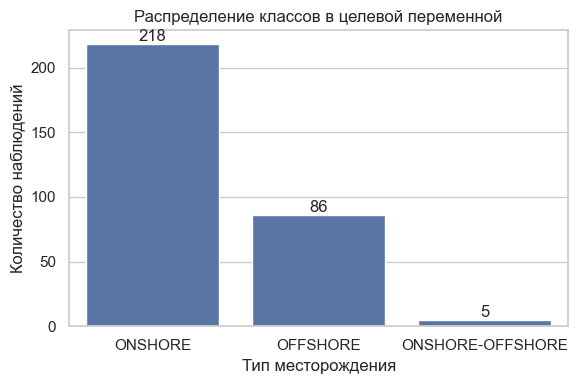

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x="Onshore/Offshore")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Распределение классов в целевой переменной")
plt.xlabel("Тип месторождения")
plt.ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

Большую часть выборки составляют месторождения типа **`ONSHORE`**, тогда как доля **`OFFSHORE`** заметно ниже.

Таким образом, в данных присутствует умеренный дисбаланс классов.
`Accuracy` здесь недостаточно как основной метрики, поэтому при сравнении моделей дополнительно будут использоваться метрики, учитывающие качество по обоим классам.

### Пропуски в данных

Перед обучением моделей необходимо определить, в каких признаках есть пропущенные значения, и выбрать подходящую стратегию их обработки для числовых и категориальных данных.

In [12]:
display(train.isna().sum())

Field name                         0
Reservoir unit                     0
Country                           27
Region                            38
Basin name                        38
Tectonic regime                    0
Latitude                          27
Longitude                         30
Operator company                   0
Onshore/Offshore                   0
Hydrocarbon type                   0
Reservoir status                   0
Structural setting                 0
Depth                              0
Reservoir period                   0
Lithology                          0
Thickness (gross average ft)       0
Thickness (net pay average ft)     0
Porosity                           0
Permeability                       0
dtype: int64

In [13]:
display((train.isna().sum() / len(train)).sort_values(ascending=False))

Region                            0.122977
Basin name                        0.122977
Longitude                         0.097087
Country                           0.087379
Latitude                          0.087379
Field name                        0.000000
Depth                             0.000000
Porosity                          0.000000
Thickness (net pay average ft)    0.000000
Thickness (gross average ft)      0.000000
Lithology                         0.000000
Reservoir period                  0.000000
Hydrocarbon type                  0.000000
Structural setting                0.000000
Reservoir status                  0.000000
Reservoir unit                    0.000000
Onshore/Offshore                  0.000000
Operator company                  0.000000
Tectonic regime                   0.000000
Permeability                      0.000000
dtype: float64

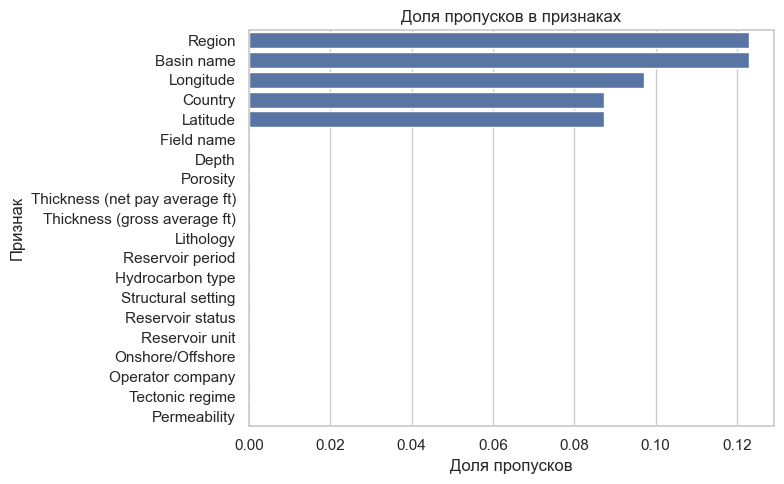

In [14]:
missing_ratio = train.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_ratio.values, y=missing_ratio.index)

plt.title("Доля пропусков в признаках")
plt.xlabel("Доля пропусков")
plt.ylabel("Признак")

plt.tight_layout()
plt.show()

Пропуски присутствуют в нескольких признаках, однако их доля остаётся относительно небольшой.

Поскольку выборка сама по себе невелика, удаление строк с пропусками может привести к нежелательной потере данных.  
Поэтому на этапе предобработки будет использоваться заполнение пропусков:

- для числовых признаков — медианой;
- для категориальных признаков — отдельным значением `Unknown`.

Эти шаги будут включены в пайплайн предобработки

### Уточнение постановки задачи

По результатам анализа целевой переменной наблюдения с классом `ONSHORE-OFFSHORE` исключаются из дальнейшего рассмотрения.

После этого задача формулируется как бинарная классификация: `ONSHORE` vs `OFFSHORE`.

In [15]:
train = train[train["Onshore/Offshore"] != "ONSHORE-OFFSHORE"].copy()

print("Размер датасета после удаления редкого класса:", train.shape)
print()
print(train["Onshore/Offshore"].value_counts())

Размер датасета после удаления редкого класса: (304, 20)

Onshore/Offshore
ONSHORE     218
OFFSHORE     86
Name: count, dtype: int64


После исключения редкого класса постановка задачи становится корректнее, но ограниченность выборки остаётся: при таком объёме данных оценка по одному разбиению может быть нестабильной.

### Связь признаков с целевой переменной

После перехода к бинарной постановке полезно проверить, есть ли в данных признаки, которые действительно различаются между классами `ONSHORE` и `OFFSHORE`.

Ниже рассмотрим несколько числовых и категориальных признаков, чтобы понять, различаются ли они между классами и могут ли быть полезны для классификации

In [16]:
eda_numeric_features = ["Depth", "Porosity", "Permeability"]

display(
    train.groupby("Onshore/Offshore")[eda_numeric_features]
    .agg(["median", "mean"])
    .round(2)
)

Depth          Porosity        Permeability        
                  median     mean   median   mean       median    mean
Onshore/Offshore                                                      
OFFSHORE          7511.5  7688.40     20.0  20.86        210.0  740.25
ONSHORE           5610.0  6464.54     15.0  16.53         42.7  376.10

Сводная таблица показывает, что классы различаются по всем трём выбранным числовым признакам.

- Для `OFFSHORE` характерны более высокие значения `Depth`: и среднее, и медиана заметно выше, чем у `ONSHORE`.
- По `Porosity` offshore-объекты также в среднем выше onshore.
- Наиболее сильное различие наблюдается по `Permeability`: у `OFFSHORE` выше и медиана, и среднее значение, хотя уже по среднему видно влияние сильной асимметрии и выбросов.

Числовые признаки действительно различаются между классами и могут быть полезны для классификации.

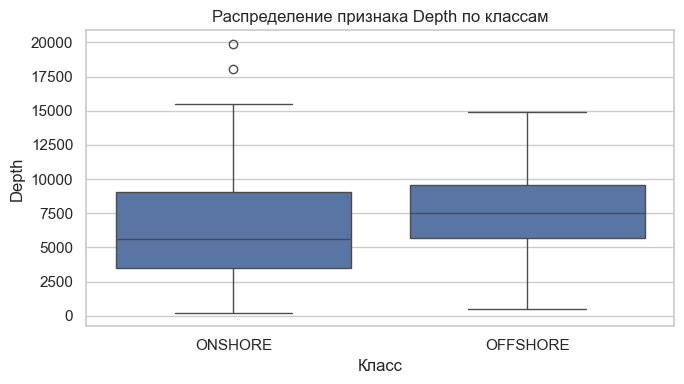

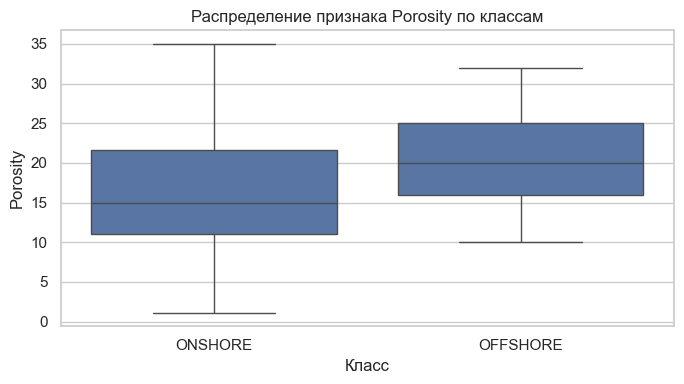

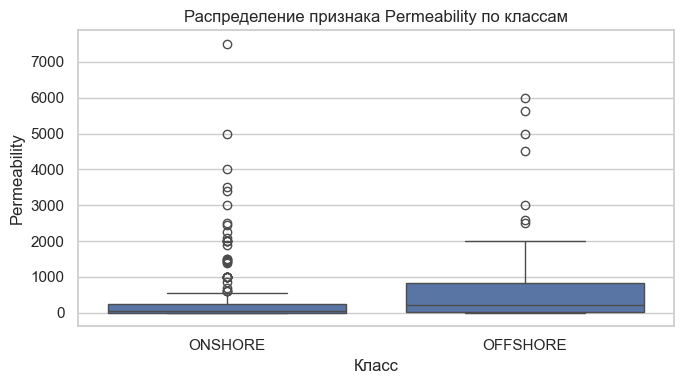

In [17]:
eda_numeric_features = ["Depth", "Porosity", "Permeability"]

for feature in eda_numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train, x="Onshore/Offshore", y=feature)
    plt.title(f"Распределение признака {feature} по классам")
    plt.xlabel("Класс")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

Boxplot подтверждают, что числовые признаки различаются между классами, но степень различия у них неодинакова.

- `Depth` выглядит наиболее информативным признаком: у `OFFSHORE` распределение в целом смещено вверх относительно `ONSHORE`, хотя между классами сохраняется заметное перекрытие.
- `Porosity` тоже показывает устойчивый сдвиг: для `OFFSHORE` медиана выше, а основная масса значений лежит в более высоком диапазоне.
- `Permeability` различает классы слабее в “чистом” виде из-за сильной асимметрии и большого числа выбросов в обоих классах. При этом у `OFFSHORE` распределение всё же в среднем смещено к более высоким значениям.

По отдельности числовые признаки не разделяют классы полностью, но в комбинации друг с другом могут давать модели полезный сигнал

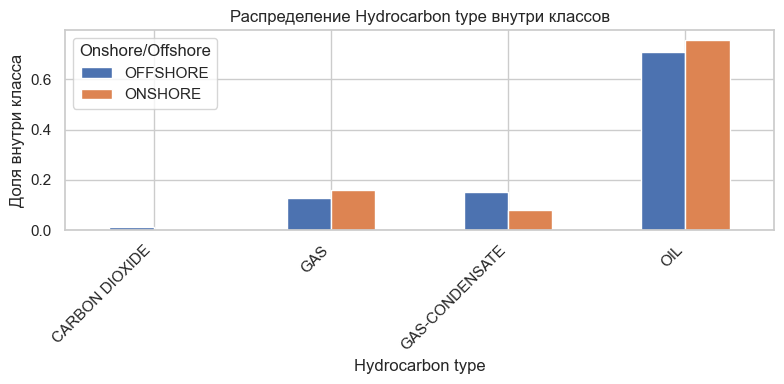

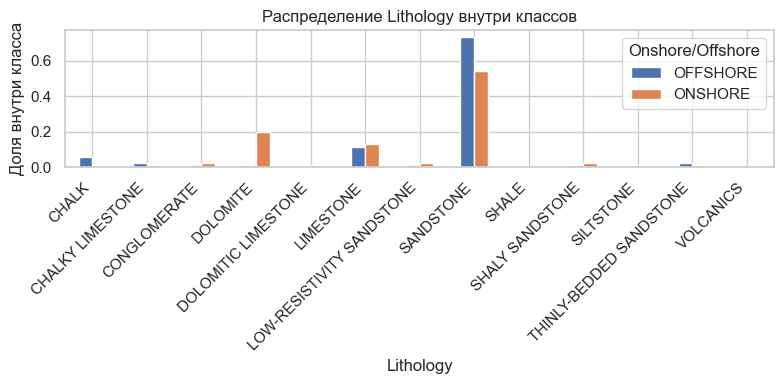

In [18]:
eda_categorical_features = ["Hydrocarbon type", "Lithology"]

for feature in eda_categorical_features:
    share_table = pd.crosstab(
        train[feature],
        train["Onshore/Offshore"],
        normalize="columns"
    ).sort_index()

    share_table.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Распределение {feature} внутри классов")
    plt.xlabel(feature)
    plt.ylabel("Доля внутри класса")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

По признаку `Hydrocarbon type` видно, что в обоих классах доминирует категория `OIL`, поэтому этот признак вряд ли обеспечивает сильное разделение сам по себе.

При этом состав классов не полностью одинаков:
- для `OFFSHORE` немного выше доля `GAS-CONDENSATE`;
- для `ONSHORE` чуть выше доля `GAS`;
- категория `CARBON DIOXIDE` встречается крайне редко и вряд ли даст устойчивый вклад в модель.

`Hydrocarbon type` содержит некоторый сигнал, но по визуальному анализу он выглядит умеренным, а не ключевым.

Признак `Lithology` выглядит более информативным, чем `Hydrocarbon type`.

В обоих классах преобладает `SANDSTONE`, однако:
- у `OFFSHORE` эта категория выражена сильнее;
- у `ONSHORE` распределение более разнообразное, и заметнее представлены, например, `DOLOMITE` и `LIMESTONE`.

`Lithology` выглядит более полезным признаком: не за счёт одной уникальной категории, а за счёт различий в распределении литологии между классами.

EDA показывает, что в данных есть предиктивный сигнал, но он распределён между несколькими признаками и не сводится к одному явному разделителю.
- Среди числовых признаков наиболее заметные различия между классами наблюдаются по `Depth` и `Porosity`; `Permeability` тоже различает классы, но его интерпретацию осложняют асимметрия и выбросы.
- Среди категориальных признаков `Hydrocarbon type` выглядит умеренно полезным, а `Lithology` показывает более выраженные различия в распределении между классами.

В целом задача классификации выглядит обоснованной: модель может опираться на комбинацию числовых и категориальных признаков, хотя полного визуального разделения классов в данных нет.

## Подготовка данных и схема валидации

Подготовим данные к моделированию: сначала выделим тренировочную и holdout-выборки, затем соберём единый пайплайн предобработки признаков.

Используем стратифицированное разбиение, чтобы сохранить распределение классов в обеих частях выборки. Holdout-выборка будет зарезервирована для финальной независимой проверки модели и не будет использоваться при выборе алгоритма.

In [19]:
X = train.drop(columns=["Onshore/Offshore"])
y = train["Onshore/Offshore"]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print("Распределение классов в train:")
print(y_train.value_counts(normalize=True))

print("\nРаспределение классов в holdout:")
print(y_holdout.value_counts(normalize=True))

Распределение классов в train:
Onshore/Offshore
ONSHORE     0.716049
OFFSHORE    0.283951
Name: proportion, dtype: float64

Распределение классов в holdout:
Onshore/Offshore
ONSHORE     0.721311
OFFSHORE    0.278689
Name: proportion, dtype: float64


Для выбора модели далее используется только тренировочная часть данных.

Holdout-выборка сохраняется как независимый набор наблюдений и используется только в финальной проверке

### Предобработка признаков

Выделим числовые и категориальные признаки и соберём пайплайн предобработки, который будет использоваться при сравнении моделей.

In [21]:
model_numeric_features = X_train.select_dtypes(include=["number"]).columns
model_categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Числовые признаки:", list(model_numeric_features))
print("Категориальные признаки:", list(model_categorical_features))

Числовые признаки: ['Latitude', 'Longitude', 'Depth', 'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability']
Категориальные признаки: ['Field name', 'Reservoir unit', 'Country', 'Region', 'Basin name', 'Tectonic regime', 'Operator company', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']


In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, model_numeric_features),
        ("cat", categorical_transformer, model_categorical_features),
    ]
)

Предобработка включена в `ColumnTransformer`, чтобы все шаги выполнялись внутри пайплайна и обучались только на тренировочной выборке. Это помогает избежать утечки данных и делает сравнение моделей более корректным.

Единая схема предобработки используется для сопоставимого сравнения моделей.  
На небольшой выборке one-hot encoding, особенно для высококардинальных признаков, может усиливать риск переобучения.

## Обучение и сравнение моделей

Сравним несколько моделей классификации в единой экспериментальной схеме:

- `DummyClassifier` — baseline;
- `LogisticRegression`;
- `KNeighborsClassifier`;
- `DecisionTreeClassifier`.

Для всех моделей используется один и тот же пайплайн: предобработка признаков через `ColumnTransformer`, затем обучение классификатора.

Поскольку выборка небольшая, сравнение проводится с помощью стратифицированной кросс-валидации на тренировочной части данных. Это позволяет получить более устойчивую оценку качества, чем один train/holdout split.

В качестве основной метрики используется `balanced_accuracy`, так как классы распределены не полностью равномерно и важно учитывать качество предсказаний по обоим классам. Дополнительно анализируются `f1_macro` и `accuracy`

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
}

cv_rows = []
trained_pipelines = {}

for model_name, model in models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    cv_scores = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    cv_rows.append({
        "model": model_name,
        "balanced_accuracy_mean": cv_scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_scores["test_balanced_accuracy"].std(),
        "f1_macro_mean": cv_scores["test_f1_macro"].mean(),
        "f1_macro_std": cv_scores["test_f1_macro"].std(),
        "accuracy_mean": cv_scores["test_accuracy"].mean(),
        "accuracy_std": cv_scores["test_accuracy"].std(),
    })

    model_pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = model_pipeline

results_df = (
    pd.DataFrame(cv_rows)
    .sort_values(
        by=["balanced_accuracy_mean", "f1_macro_mean", "accuracy_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

results_df.insert(0, "rank", range(1, len(results_df) + 1))

metric_columns = [
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "f1_macro_mean",
    "f1_macro_std",
    "accuracy_mean",
    "accuracy_std",
]

results_display_df = results_df.copy()
results_display_df[metric_columns] = results_display_df[metric_columns].round(3)

display(results_display_df)

,rank,model,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,accuracy_mean,accuracy_std
0,1,LogisticRegression,0.824,0.030,0.837,0.035,0.872,0.031
1,2,DecisionTreeClassifier,0.800,0.078,0.795,0.077,0.831,0.063
2,3,KNeighborsClassifier,0.718,0.037,0.727,0.036,0.790,0.025
3,4,DummyClassifier,0.500,0.000,0.417,0.002,0.716,0.007


Сравнение по кросс-валидации показывает, что все обучаемые модели превосходят `DummyClassifier`, а значит признаки действительно содержат полезный сигнал для классификации.

Лучший средний результат по `balanced_accuracy` на тренировочной части показала `LogisticRegression`. `DecisionTreeClassifier` дал близкое среднее качество, но с более высоким разбросом между фолдами, что может указывать на меньшую устойчивость модели на разных разбиениях. `KNeighborsClassifier` также превзошёл baseline, но заметно уступил двум лидирующим моделям.

На небольшой выборке полезно смотреть не только на среднее значение метрики, но и на разброс между фолдами: он помогает оценить, насколько стабильно модель ведёт себя на разных разбиениях.

## Проверка гипотезы о высококардинальных признаках

На этапе EDA было замечено, что признаки `Field name`, `Reservoir unit`, `Operator company` и `Basin name` обладают высокой кардинальностью.

Для небольшой выборки такие признаки могут быть проблемными:
- они резко увеличивают число столбцов после one-hot encoding
- часть категорий встречается слишком редко
- отдельные признаки могут начать работать почти как идентификаторы, а не как устойчивые источники сигнала

Чтобы проверить, насколько они действительно полезны, сравним две версии одной и той же модели:
- со всеми признаками
- без наиболее подозрительных высококардинальных признаков

Сравнение проводится на тренировочной части с помощью той же схемы стратифицированной кросс-валидации

In [25]:
high_cardinality_features = [
    col for col in ["Field name", "Reservoir unit", "Operator company", "Basin name"]
    if col in X_train.columns
]

best_model_name = results_df.loc[0, "model"]

X_train_reduced = X_train.drop(columns=high_cardinality_features)

reduced_numeric_features = X_train_reduced.select_dtypes(include=["number"]).columns
reduced_categorical_features = X_train_reduced.select_dtypes(include=["object"]).columns

reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, reduced_numeric_features),
        ("cat", categorical_transformer, reduced_categorical_features),
    ]
)

feature_set_variants = {
    "all_features": {
        "X": X_train,
        "preprocessor": preprocessor,
    },
    "without_high_cardinality": {
        "X": X_train_reduced,
        "preprocessor": reduced_preprocessor,
    },
}

feature_set_rows = []

for feature_set_name, feature_set_params in feature_set_variants.items():
    feature_set_pipeline = Pipeline(steps=[
        ("preprocessor", feature_set_params["preprocessor"]),
        ("model", clone(models[best_model_name])),
    ])

    feature_set_scores = cross_validate(
        estimator=feature_set_pipeline,
        X=feature_set_params["X"],
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    feature_set_rows.append({
        "feature_set": feature_set_name,
        "balanced_accuracy_mean": feature_set_scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": feature_set_scores["test_balanced_accuracy"].std(),
        "f1_macro_mean": feature_set_scores["test_f1_macro"].mean(),
        "f1_macro_std": feature_set_scores["test_f1_macro"].std(),
        "accuracy_mean": feature_set_scores["test_accuracy"].mean(),
        "accuracy_std": feature_set_scores["test_accuracy"].std(),
    })

feature_set_results_df = (
    pd.DataFrame(feature_set_rows)
    .sort_values(
        by=["balanced_accuracy_mean", "f1_macro_mean", "accuracy_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_metric_columns = [
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "f1_macro_mean",
    "f1_macro_std",
    "accuracy_mean",
    "accuracy_std",
]

feature_set_display_df = feature_set_results_df.copy()
feature_set_display_df[feature_metric_columns] = (
    feature_set_display_df[feature_metric_columns].round(3)
)

feature_set_display_df["feature_set"] = feature_set_display_df["feature_set"].map({
    "all_features": "Все признаки",
    "without_high_cardinality": "Без high-cardinality признаков",
})

display(feature_set_display_df)

,feature_set,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,accuracy_mean,accuracy_std
0,Все признаки,0.824,0.030,0.837,0.035,0.872,0.031
1,Без high-cardinality признаков,0.814,0.022,0.817,0.034,0.852,0.033


Эксперимент показывает, что удаление высококардинальных признаков немного снижает качество модели по основным метрикам. Это указывает на то, что такие признаки действительно содержат полезный сигнал.
При этом часть прироста может быть связана с прокси-сигналом, поэтому результат стоит интерпретировать осторожно: хорошее качество на случайном разбиении не гарантирует такого же качества на новых регионах, бассейнах или группах объектов.

## Проверка итоговой модели на holdout-выборке

По результатам кросс-валидации на тренировочной части в качестве основного алгоритма была выбрана `LogisticRegression`.

Дополнительный эксперимент с high-cardinality признаками показал, что их полное исключение немного снижает среднее качество модели по всем основным метрикам, хотя и делает результат чуть менее вариативным. Поэтому для финальной проверки выбрана конфигурация `LogisticRegression` со всеми признаками.

In [26]:
display(best_model_name)

'LogisticRegression'

In [27]:
best_pipeline = trained_pipelines[best_model_name]

holdout_pred = best_pipeline.predict(X_holdout)

holdout_balanced_accuracy = balanced_accuracy_score(y_holdout, holdout_pred)
holdout_f1_macro = f1_score(y_holdout, holdout_pred, average="macro")
holdout_accuracy = accuracy_score(y_holdout, holdout_pred)

print(classification_report(y_holdout, holdout_pred))
print(f"Holdout balanced_accuracy: {holdout_balanced_accuracy:.3f}")
print(f"Holdout f1_macro: {holdout_f1_macro:.3f}")
print(f"Holdout accuracy: {holdout_accuracy:.3f}")

              precision    recall  f1-score   support

    OFFSHORE       0.75      0.71      0.73        17
     ONSHORE       0.89      0.91      0.90        44

    accuracy                           0.85        61
   macro avg       0.82      0.81      0.81        61
weighted avg       0.85      0.85      0.85        61

Holdout balanced_accuracy: 0.807
Holdout f1_macro: 0.813
Holdout accuracy: 0.852


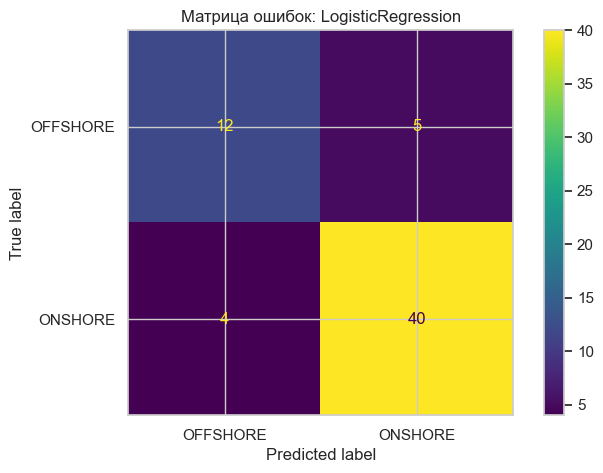

In [28]:
ConfusionMatrixDisplay.from_predictions(y_holdout, holdout_pred)
plt.title(f"Матрица ошибок: {best_model_name}")
plt.show()

По результатам кросс-валидации для проверки на holdout-выборке была выбрана модель с наилучшим средним значением `balanced_accuracy`.

Разбор метрик по классам показывает, что:
- модель хорошо распознаёт класс `ONSHORE` (`recall = 0.91`)
- для класса `OFFSHORE` качество ниже (`recall = 0.71`), и часть наблюдений этого класса остаётся ошибочно классифицированной

Это означает, что высокая общая точность (`accuracy = 0.85`) не полностью отражает качество работы по менее представленному классу.

Результат на holdout выглядит устойчивым, но из-за небольшого объёма данных и высококардинальных категориальных признаков его всё же стоит интерпретировать осторожно.

## Интерпретация итоговой модели

Для финальной проверки была выбрана LogisticRegression, поэтому далее можно посмотреть на коэффициенты модели после one-hot encoding.

Такой анализ полезен как ориентир, но его следует трактовать осторожно:
- после one-hot encoding один исходный категориальный признак распадается на множество бинарных столбцов
- величины коэффициентов чувствительны к особенностям кодирования
- высокая кардинальность отдельных категориальных признаков может усиливать нестабильность оценок на небольшой выборке

Поэтому коэффициенты здесь используются не как окончательная мера важности признаков, а как инструмент общей интерпретации модели

In [29]:
fitted_model = best_pipeline.named_steps["model"]

if not isinstance(fitted_model, LogisticRegression):
    raise TypeError(
        "Интерпретация коэффициентов реализована только для LogisticRegression."
    )

transformed_feature_names = (
    best_pipeline.named_steps["preprocessor"].get_feature_names_out()
)

positive_class = fitted_model.classes_[1]
negative_class = fitted_model.classes_[0]

print(f"Положительный класс для интерпретации коэффициентов: {positive_class}")
print(f"Отрицательный класс: {negative_class}")

coef_df = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "coefficient": fitted_model.coef_[0],
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df["feature_type"] = (
    coef_df["transformed_feature"]
    .str.extract(r"^(num|cat)__")[0]
    .map({"num": "numeric", "cat": "categorical"})
)

coef_df["feature"] = (
    coef_df["transformed_feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_positive_coef_df = (
    coef_df.sort_values(by="coefficient", ascending=False)
    .head(7)[["feature", "feature_type", "coefficient"]]
)

top_negative_coef_df = (
    coef_df.sort_values(by="coefficient", ascending=True)
    .head(7)[["feature", "feature_type", "coefficient"]]
)

top_numeric_coef_df = (
    coef_df[coef_df["feature_type"] == "numeric"]
    .sort_values(by="abs_coefficient", ascending=False)
    .head(7)[["feature", "coefficient", "abs_coefficient"]]
)

print("\nНаиболее положительные коэффициенты:")
display(top_positive_coef_df.round(3))

print("Наиболее отрицательные коэффициенты:")
display(top_negative_coef_df.round(3))

print("Числовые признаки с наибольшим модулем коэффициента:")
display(top_numeric_coef_df.round(3))

Положительный класс для интерпретации коэффициентов: ONSHORE
Отрицательный класс: OFFSHORE

Наиболее положительные коэффициенты:


,feature,feature_type,coefficient
564,Tectonic regime_COMPRESSION,categorical,1.119
745,Structural setting_FORELAND,categorical,0.928
749,Structural setting_INTRACRATONIC,categorical,0.838
510,Basin name_GULF OF MEXICO NORTHERN ONSHORE,categorical,0.785
733,Reservoir status_NEARLY DEPLETED,categorical,0.673
472,Country_USA,categorical,0.668
685,Operator company_PETROCHINA,categorical,0.665


Наиболее отрицательные коэффициенты:


,feature,feature_type,coefficient
476,Region_EUROPE,categorical,-1.277
731,Reservoir status_DEVELOPING,categorical,-1.221
470,Country_UK,categorical,-0.998
632,Operator company_CHEVRON,categorical,-0.786
588,Tectonic regime_GRAVITY/EVAPORITE/COMPRESSION,categorical,-0.717
581,Tectonic regime_EXTENSION/EROSION,categorical,-0.604
525,Basin name_NORTH SEA NORTHERN,categorical,-0.596


Числовые признаки с наибольшим модулем коэффициента:


,feature,coefficient,abs_coefficient
5,Porosity,-0.568,0.568
2,Depth,-0.563,0.563
4,Thickness (net pay average ft),-0.321,0.321
1,Longitude,-0.279,0.279
0,Latitude,0.214,0.214
6,Permeability,0.152,0.152
3,Thickness (gross average ft),-0.062,0.062


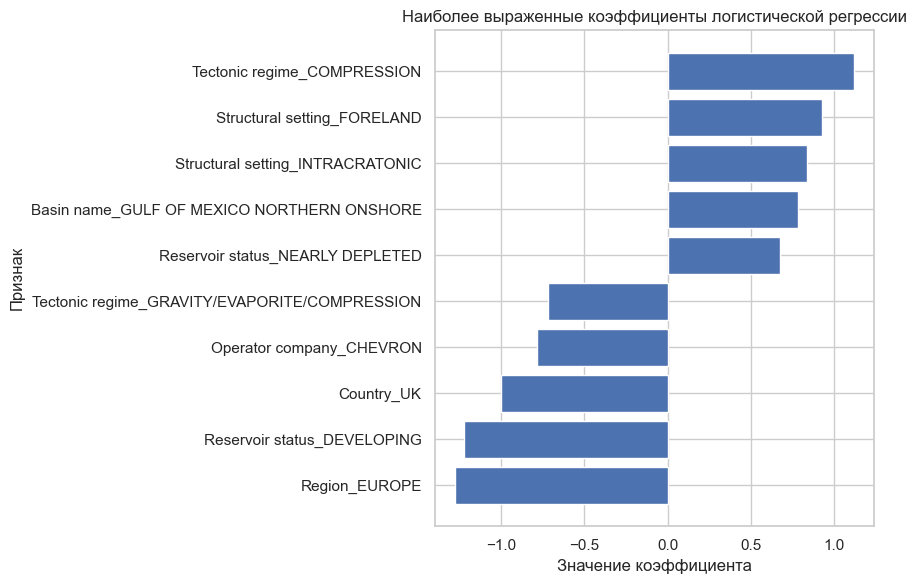

In [30]:
coef_plot_df = (
    pd.concat([
        coef_df.sort_values(by="coefficient", ascending=True).head(5),
        coef_df.sort_values(by="coefficient", ascending=False).head(5),
    ])
    .drop_duplicates(subset="feature")
    .sort_values(by="coefficient")
)

plt.figure(figsize=(9, 6))
plt.barh(coef_plot_df["feature"], coef_plot_df["coefficient"])
plt.title("Наиболее выраженные коэффициенты логистической регрессии")
plt.xlabel("Значение коэффициента")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

В текущей модели среди наиболее выраженных коэффициентов преобладают отдельные уровни категориальных признаков после one-hot encoding. Это значит, что интерпретация идёт не на уровне исходных категориальных столбцов целиком, а на уровне конкретных бинарных индикаторов, созданных после кодирования.

Положительный класс модели — `ONSHORE`, поэтому:
- положительные коэффициенты связаны с большей склонностью предсказывать `ONSHORE`
- отрицательные коэффициенты — с большей склонностью предсказывать `OFFSHORE`

Среди наиболее сильных положительных коэффициентов в сторону `ONSHORE` выделяются категории, связанные с тектоническим режимом, структурной обстановкой, статусом месторождения и географическими признаками. Среди наиболее сильных отрицательных коэффициентов в сторону `OFFSHORE` также преобладают категориальные индикаторы, в том числе признаки, связанные с регионом, страной, оператором и отдельными бассейнами.

Среди числовых признаков наибольший модуль коэффициента наблюдается у `Porosity` и `Depth`: в текущей модели оба признака имеют отрицательный знак и связаны с большей склонностью предсказывать `OFFSHORE`. Признаки `Permeability` и `Latitude` имеют положительный знак, но их вклад выглядит менее выраженным.

Такой анализ не стоит трактовать как окончательный рейтинг важности признаков:
- один исходный категориальный признак после one-hot encoding распадается на множество отдельных коэффициентов
- редкие категории и высокая кардинальность могут делать оценки нестабильными на небольшой выборке
- часть сильных категориальных коэффициентов может отражать не универсальные закономерности, а особенности текущей выборки

Коэффициенты логистической регрессии здесь полезны прежде всего как инструмент предварительного качественного чтения модели: они помогают понять направление влияния признаков, но не дают окончательного объяснения структуры данных

## Выводы

В проекте была решена задача бинарной классификации месторождений `ONSHORE` и `OFFSHORE`. Редкий класс `ONSHORE-OFFSHORE` был исключён из анализа, поскольку на небольшой выборке его сохранение делало бы задачу менее устойчивой и усложняло бы интерпретацию результатов.

На этапе EDA были проанализированы структура данных, пропуски, распределение целевой переменной и кардинальность категориальных признаков. Дополнительно был выполнен анализ связи признаков с целевой переменной: числовые признаки `Depth`, `Porosity` и `Permeability` показали различия между классами, а среди категориальных признаков наиболее заметный сигнал наблюдался в распределениях `Lithology` и в меньшей степени `Hydrocarbon type`. Это подтвердило, что в данных действительно присутствует предиктивный сигнал.

Для корректной оценки модели данные были разделены на тренировочную и holdout-выборки. Все решения о выборе алгоритма принимались только на тренировочной части с помощью стратифицированной кросс-валидации.

В единой схеме были сравнены `DummyClassifier`, `LogisticRegression`, `KNeighborsClassifier` и `DecisionTreeClassifier`. Основной метрикой выступала `balanced_accuracy`, дополнительно анализировались `f1_macro` и `accuracy`. Лучший результат показала `LogisticRegression` (`balanced_accuracy = 0.824 ± 0.030`), при этом её преимущество над `DecisionTreeClassifier` оказалось умеренным.

Отдельно была проверена гипотеза о влиянии высококардинальных признаков (`Field name`, `Reservoir unit`, `Operator company`, `Basin name`). Эксперимент показал, что их удаление немного снижает среднее качество модели (`balanced_accuracy` снижается с 0.824 до 0.814), хотя и делает результат менее вариативным. Это указывает на наличие полезного сигнала, но часть прироста качества может быть связана не с устойчивыми закономерностями, а с частичным запоминанием отдельных категорий.

Финальная оценка на holdout-выборке показала `balanced_accuracy = 0.81`, `accuracy = 0.85`, `f1_macro = 0.81`. Модель хорошо распознаёт класс `ONSHORE` (`recall = 0.91`), однако качество по классу `OFFSHORE` ниже (`recall = 0.71`), и часть наблюдений этого класса продолжает классифицироваться ошибочно.

Интерпретация коэффициентов логистической регрессии показала, что в верхней части списка доминируют отдельные уровни категориальных признаков после one-hot encoding, тогда как среди числовых признаков наиболее заметный вклад дают `Porosity` и `Depth`. Такой анализ помогает качественно понять направление влияния признаков, но не является окончательным рейтингом их важности.

Основные ограничения текущей версии проекта:
- небольшой объём выборки
- наличие высококардинальных категориальных признаков
- чувствительность интерпретации коэффициентов к one-hot encoding
- отсутствие более глубокого подбора гиперпараметров и альтернативных способов кодирования категорий

В целом ноутбук показывает полный аналитический контур решения задачи: от постановки проблемы и EDA до сравнения моделей, проверки гипотез о признаках и финальной оценки на holdout. Следующим шагом является перенос воспроизводимого обучения, сохранения модели и inference-пайплайна в src-часть проекта.